In [57]:
import pandas as pd

raw = pd.read_csv('데이터/scada 경주/WTG01_총정보.csv')

df = pd.DataFrame({
  'dt': pd.to_datetime(raw["Date/Time"]),
  'kwh': raw['energy_kwh']})

df = df.set_index('dt')

df["dayofyear"] = df.index.dayofyear
df["hour"] = df.index.hour

df.dropna(inplace=True)

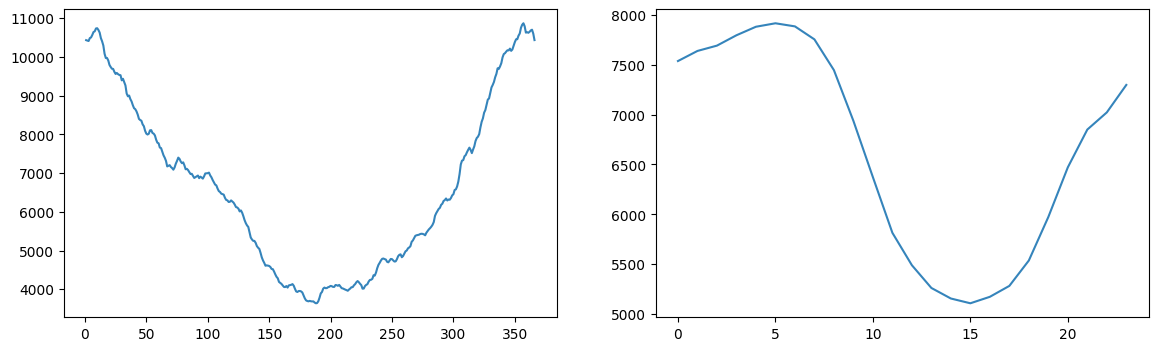

In [58]:
import matplotlib.pyplot as plt

window_size = 60

plt.figure(figsize=(14, 4))
plt.subplot(1,2,1)
df_tmp = df.groupby(df.index.dayofyear).mean()
df_extended = pd.concat([df_tmp.iloc[-window_size:], df_tmp, df_tmp.iloc[:window_size]])
df_doy = df_extended.rolling(window=window_size, center=True).mean().iloc[window_size:-window_size]
plt.plot(df_doy.index, df_doy['kwh'], alpha=0.9)

plt.subplot(1,2,2)
df_hour = df.groupby(df.index.hour).mean()
plt.plot(df_hour.index, df_hour['kwh'], alpha=0.9)
plt.show()

In [59]:
import torch

mean = df['kwh'].mean()
doy_bias = torch.zeros(367)
doy_bias[1:] = torch.tensor(df_doy['kwh'].values, dtype=torch.float) - mean
hour_bias = torch.zeros(24)
hour_bias[:] = torch.tensor(df_hour['kwh'].values, dtype=torch.float) - mean

def baseline_estimator(doy, hour):
  return mean + doy_bias[doy] + hour_bias[hour]

df['baseline'] = baseline_estimator(df['dayofyear'].values, df['hour'].values).numpy()

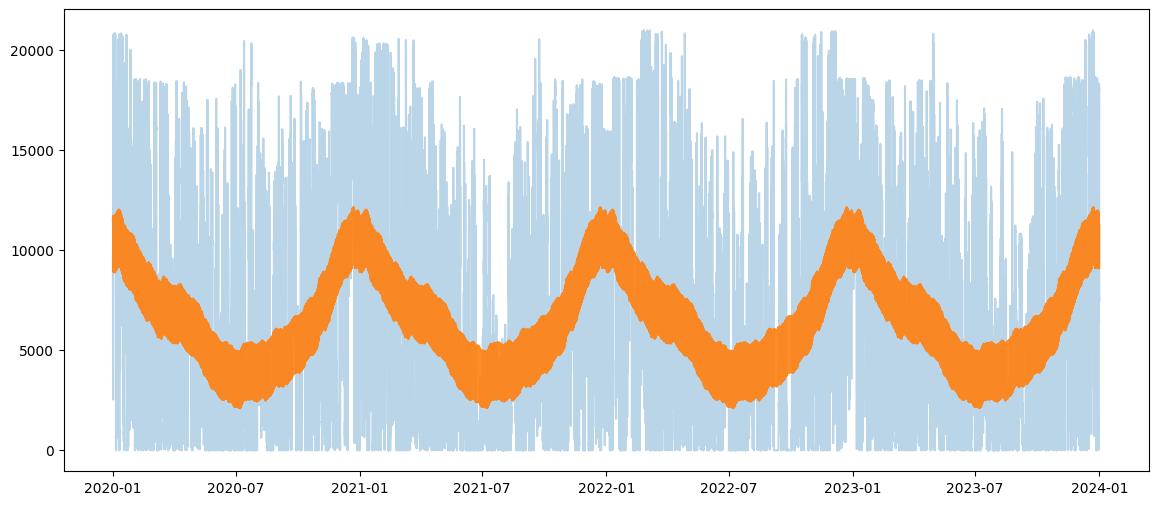

In [60]:
plt.figure(figsize=(14, 6))
# df_day = df.resample('D').mean()
plt.plot(df.index, df['kwh'], alpha=0.3)
plt.plot(df.index, df['baseline'], alpha=0.9)
plt.show()

In [61]:
df

,kwh,dayofyear,hour,baseline
dt,,,,
2020-01-01 01:00:00,9767.578125,1,1,11434.179688
2020-01-01 02:00:00,5381.835938,1,2,11487.537109
2020-01-01 03:00:00,3021.484375,1,3,11591.404297
2020-01-01 04:00:00,4400.390625,1,4,11676.849609
2020-01-01 05:00:00,4501.953125,1,5,11711.652344
...,...,...,...,...
2023-12-31 19:00:00,13666.015625,365,19,9938.298828
2023-12-31 20:00:00,11869.140625,365,20,10436.209961
2023-12-31 21:00:00,11761.718750,365,21,10815.115234


In [62]:
pred = pd.DataFrame({
    "plant_name": "경주풍력",
    "start_datetime": df.index - pd.Timedelta(hours = 1),
    "end_datetime": df.index,
    "yield_kwh": df["baseline"]
})

In [63]:
pred = pred.reset_index(drop = True)

In [64]:
pred

,plant_name,start_datetime,end_datetime,yield_kwh
0,경주풍력,2020-01-01 00:00:00,2020-01-01 01:00:00,11434.179688
1,경주풍력,2020-01-01 01:00:00,2020-01-01 02:00:00,11487.537109
2,경주풍력,2020-01-01 02:00:00,2020-01-01 03:00:00,11591.404297
3,경주풍력,2020-01-01 03:00:00,2020-01-01 04:00:00,11676.849609
4,경주풍력,2020-01-01 04:00:00,2020-01-01 05:00:00,11711.652344
...,...,...,...,...
35058,경주풍력,2023-12-31 18:00:00,2023-12-31 19:00:00,9938.298828
35059,경주풍력,2023-12-31 19:00:00,2023-12-31 20:00:00,10436.209961
35060,경주풍력,2023-12-31 20:00:00,2023-12-31 21:00:00,10815.115234
35061,경주풍력,2023-12-31 21:00:00,2023-12-31 22:00:00,10987.158203


In [65]:
pred.to_csv("경주_예측/baseline.csv", index = False)